In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, RobustScaler, FunctionTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from catboost import CatBoostClassifier
import gc
import optuna
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1778494587.060217     468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778494587.511437     468 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778494589.049531     468 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

W0000 00:00:1778494590.218163     468 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Выполнен запрос к среде выполнения TensorFlow для получения перечня физических устройств типа GPU (графические процессоры), доступных для аппаратного ускорения вычислений. Функция возвращает список объектов `PhysicalDevice`, каждый из которых представляет собой обнаруженное GPU-устройство. В случае отсутствия GPU-устройств либо отсутствия корректно установленных драйверов CUDA возвращается пустой список. Данная диагностическая процедура применяется для верификации доступности аппаратного ускорителя перед запуском вычислительно интенсивных операций (обучение нейронных сетей, градиентный бустинг на GPU).

In [3]:
!nvidia-smi

Mon May 11 15:16:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.01              Driver Version: 596.36         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti     On  |   00000000:02:00.0  On |                  N/A |
|  0%   41C    P8             19W /  300W |     710MiB /  16303MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Выполнена диагностическая команда `nvidia-smi` (NVIDIA System Management Interface) для получения детальной информации о состоянии графических процессоров NVIDIA в системе. Интерфейс командной строки возвращает следующие сведения:

- **Версия драйвера** и версия CUDA, поддерживаемая драйвером
- **Список GPU-устройств** с идентификаторами, моделями и объёмом видеопамяти
- **Текущая загрузка GPU** (процент использования вычислительных ядер)
- **Использование видеопамяти** (занято / всего, в MiB или GiB)
- **Температура GPU** (в градусах Цельсия)
- **Энергопотребление** (текущее и максимальное)
- **Запущенные процессы**, использующие GPU (включая идентификаторы процессов и объём занятой памяти)

Данная команда является стандартным инструментом мониторинга и диагностики в средах с NVIDIA GPU, позволяющим подтвердить доступность аппаратного ускорителя перед выполнением вычислительных задач (например, обучения CatBoost с `task_type='GPU'` или TensorFlow/Keras-моделей).

# Данные

**Задача кредитного скоринга**

Набор данных состоит из 100 000 строк и 28 функций. Он предоставляет широкий обзор финансовой жизни клиента, от базовых демографических данных до сложной банковской истории.

Демографические данные: возраст, род занятий.
Финансовые показатели: Годовой доход, Ежемесячный баланс, Непогашенная задолженность.
Банковская история: Количество банковских счетов, Количество кредитов, процентные ставки.
Целевая переменная: Credit_Score.

https://huggingface.co/datasets/Davichick/Credit-score-analysis

In [4]:
from datasets import load_dataset

ds = load_dataset("Davichick/Credit-score-analysis")

Произведена загрузка структурированного набора данных «Credit-score-analysis» из репозитория Hugging Face (автор: Davichick) с использованием библиотеки `datasets`. Объект `ds` инициализирован и содержит данные для анализа кредитных скоринговых показателей. Структура датасета может включать информацию о заёмщиках (демографические характеристики, кредитную историю, финансовые показатели) и целевую переменную, отражающую кредитный рейтинг или категорию риска. Даталогический объект готов к последующей предобработке, исследовательскому анализу и построению моделей классификации или регрессии в зависимости от характера целевой переменной.

In [5]:
df = ds['train'].to_pandas()

del ds

df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.86622816574095,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.651610435322,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.8090832742814,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.1649785257098,Standard


Выполнена конвертация обучающей выборки загруженного датасета «Credit-score-analysis» в объект pandas DataFrame. Исходный объект `ds` удалён из оперативной памяти с целью оптимизации использования вычислительных ресурсов и освобождения места для последующих операций обработки данных. Результирующий DataFrame `df` содержит структурированное представление кредитных скоринговых наблюдений и готов к выполнению процедур предварительной обработки, разведочного анализа, проверки на пропуски и аномалии, а также к последующему моделированию.

In [6]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  str    
 1   Customer_ID               100000 non-null  str    
 2   Month                     100000 non-null  str    
 3   Name                      90015 non-null   str    
 4   Age                       100000 non-null  str    
 5   SSN                       100000 non-null  str    
 6   Occupation                100000 non-null  str    
 7   Annual_Income             100000 non-null  str    
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  str    
 13  Type_of_Loan              88592 non-null   str    
 14  

Проведён структурный анализ загруженного датасета «Credit-score-analysis» с использованием метода `info()`. Установлены следующие характеристики:

**Объём данных**: 100 000 записей (индексация от 0 до 99 999).

**Размерность**: 28 признаковых колонок.

**Типология переменных**:
- Строковые типы (`str`) — 20 колонок, включая идентификаторы (`ID`, `Customer_ID`), категориальные признаки (`Occupation`, `Credit_Mix`, `Payment_Behaviour`, `Credit_Score` и др.) и числовые значения, ошибочно хранящиеся в строковом формате (например, `Annual_Income`, `Num_of_Loan`, `Outstanding_Debt`).
- Целочисленные типы (`int64`) — 4 колонки (`Num_Bank_Accounts`, `Num_Credit_Card`, `Interest_Rate`, `Delay_from_due_date`).
- Вещественные типы (`float64`) — 4 колонки (`Monthly_Inhand_Salary`, `Num_Credit_Inquiries`, `Credit_Utilization_Ratio`, `Total_EMI_per_month`).

**Наличие пропусков**: 9 колонок содержат неполные данные, наиболее значительные дефекты наблюдаются в признаках `Monthly_Inhand_Salary` (84 998 непустых, 15 002 пропуска), `Type_of_Loan` (88 592 непустых, 11 408 пропусков), `Credit_History_Age` (90 970 непустых, 9 030 пропусков) и `Name` (90 015 непустых, 9 985 пропусков).

**Целевая переменная**: `Credit_Score` имеет строковый тип и, вероятно, содержит категориальные значения (например, «Good», «Standard», «Poor»), что указывает на задачу многоклассовой классификации.

**Объём памяти**: DataFrame занимает приблизительно 43.2 МБ.

**Замечания по качеству данных**: Обнаружены признаки с числовой семантикой, представленные в строковом формате (например, `Annual_Income`, `Num_of_Delayed_Payment`, `Outstanding_Debt`, `Amount_invested_monthly`, `Monthly_Balance`), требующие приведения к числовым типам с обработкой нечисловых значений. Также присутствуют категориальные признаки с высокой кардинальностью (`Type_of_Loan`, `Occupation`), потенциально требующие кодирования или извлечения дополнительных признаков.

Таргет - Credit_Score 3 уникальных значений

В данных есть много спцифических столцов, которые мы можем игнорировать.

Данные очень грязные, будем очищать

In [8]:
del df['ID'], df['Customer_ID'], df['Month'], df['Name'], df['SSN']

Выполнено удаление пяти признаков, не несущих предсказательной ценности для задачи классификации кредитного скоринга: `ID` (уникальный идентификатор записи), `Customer_ID` (идентификатор клиента), `Month` (временная метка, не имеющая стандартизированного формата), `Name` (имя заёмщика) и `SSN` (номер социального страхования). Данные колонки являются идентификационными либо обладают высокой кардинальностью при отсутствии устойчивой корреляции с целевой переменной. Удаление выполнено в целях снижения размерности признакового пространства, предотвращения переобучения и уменьшения требования к оперативной памяти. Размерность DataFrame уменьшена с 28 до 23 колонок.

In [9]:
# ================================================================
# Существует множество числовых столбцов, которые относятся к объектному типу.
# Рассмотрим "Возраст" в качестве примера.
# ================================================================

print(df['Age'].unique()[:20])

<ArrowStringArray>
[  '23', '-500',  '28_',   '28',   '34',   '54',   '55',   '21',   '31',
   '33',  '34_', '7580',   '30',  '30_',   '24',  '24_',   '44',   '45',
   '40',   '41']
Length: 20, dtype: str


In [10]:
# ================================================================
# Список столбцов, которые мы определили как объектные, но которые должны быть числовыми.
# ================================================================

cols_to_fix = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment',
               'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_to_fix:
    # Удалим символ "_" и преобразуем в числовой.
    # errors="coerce" преобразует любой оставшийся недопустимый текст в NaN.
    df[col] = pd.to_numeric(df[col].astype(str).str.replace('_', ''), errors='coerce')

print(df[cols_to_fix].dtypes)

Age                          int64
Annual_Income              float64
Num_of_Loan                  int64
Num_of_Delayed_Payment     float64
Changed_Credit_Limit       float64
Outstanding_Debt           float64
Amount_invested_monthly    float64
Monthly_Balance            float64
dtype: object


In [11]:
# ================================================================
# В этом наборе данных отсутствующие профессии записываются как "_______".
# Нам нужно заменить эту конкретную строку на "Неизвестную".
# ================================================================

df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')

print(df['Occupation'].value_counts())

Occupation
Unknown          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64


In [12]:
# Проверим другой столбец категорий на наличие аналогичных проблем.
print(df['Credit_Mix'].value_counts())

Credit_Mix
Standard    36479
Good        24337
_           20195
Bad         18989
Name: count, dtype: int64


In [13]:
# ================================================================
# Определим найденные ненужные значения.
# ================================================================

placeholders = ['_', '_______']

# Применим замену ко всему фрейму данных для обеспечения согласованности.
# Это позволит найти эти строки в любом столбце и заменить их на "Неизвестно".
df = df.replace(placeholders, 'Unknown')

print(df['Credit_Mix'].value_counts())

Credit_Mix
Standard    36479
Good        24337
Unknown     20195
Bad         18989
Name: count, dtype: int64


In [14]:
# ================================================================
# Проверим диапазон возраста и годовой доход, чтобы установить ограничение для визуализации участка.
# ================================================================

print(df[['Age', 'Annual_Income']].describe())

                 Age  Annual_Income
count  100000.000000   1.000000e+05
mean      110.649700   1.764157e+05
std       686.244717   1.429618e+06
min      -500.000000   7.005930e+03
25%        24.000000   1.945750e+04
50%        33.000000   3.757861e+04
75%        42.000000   7.279092e+04
max      8698.000000   2.419806e+07


In [15]:
# ================================================================
# Выберем больше числовых столбцов, чтобы проверить наличие нереалистичных значений
# ================================================================

check_cols = ['Num_Bank_Accounts', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Interest_Rate']

print(df[check_cols].describe())

       Num_Bank_Accounts    Num_of_Loan  Num_of_Delayed_Payment  Interest_Rate
count      100000.000000  100000.000000            92998.000000  100000.000000
mean           17.091280       3.009960               30.923342      72.466040
std           117.404834      62.647879              226.031892     466.422621
min            -1.000000    -100.000000               -3.000000       1.000000
25%             3.000000       1.000000                9.000000       8.000000
50%             6.000000       3.000000               14.000000      13.000000
75%             7.000000       5.000000               18.000000      20.000000
max          1798.000000    1496.000000             4397.000000    5797.000000


In [16]:
# ================================================================
# Исправление отклонений путем замены нереалистичных значений медианой столбца и установки порогового значения для конкретных столбцов.
# ================================================================

# Правка Age (18-100)
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = df['Age'].median()

# Правка Bank Accounts (0-20)
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = df['Num_Bank_Accounts'].median()

# Правка Number of Loans (0-15)
df.loc[(df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 15), 'Num_of_Loan'] = df['Num_of_Loan'].median()

# Правка Interest Rate (1-40)
df.loc[(df['Interest_Rate'] < 1) | (df['Interest_Rate'] > 40), 'Interest_Rate'] = df['Interest_Rate'].median()

In [17]:
cleaned_cols = ['Age', 'Annual_Income', 'Num_Bank_Accounts', 'Num_of_Loan', 'Interest_Rate']
df[cleaned_cols].describe()

,Age,Annual_Income,Num_Bank_Accounts,Num_of_Loan,Interest_Rate
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,34.308540,1.764157e+05,5.377530,3.510550,14.500450
std,9.693148,1.429618e+06,2.576402,2.395985,8.653109
min,18.000000,7.005930e+03,0.000000,0.000000,1.000000
25%,27.000000,1.945750e+04,3.000000,2.000000,8.000000
50%,33.000000,3.757861e+04,6.000000,3.000000,13.000000
75%,41.000000,7.279092e+04,7.000000,5.000000,20.000000
max,100.000000,2.419806e+07,18.000000,9.000000,34.000000


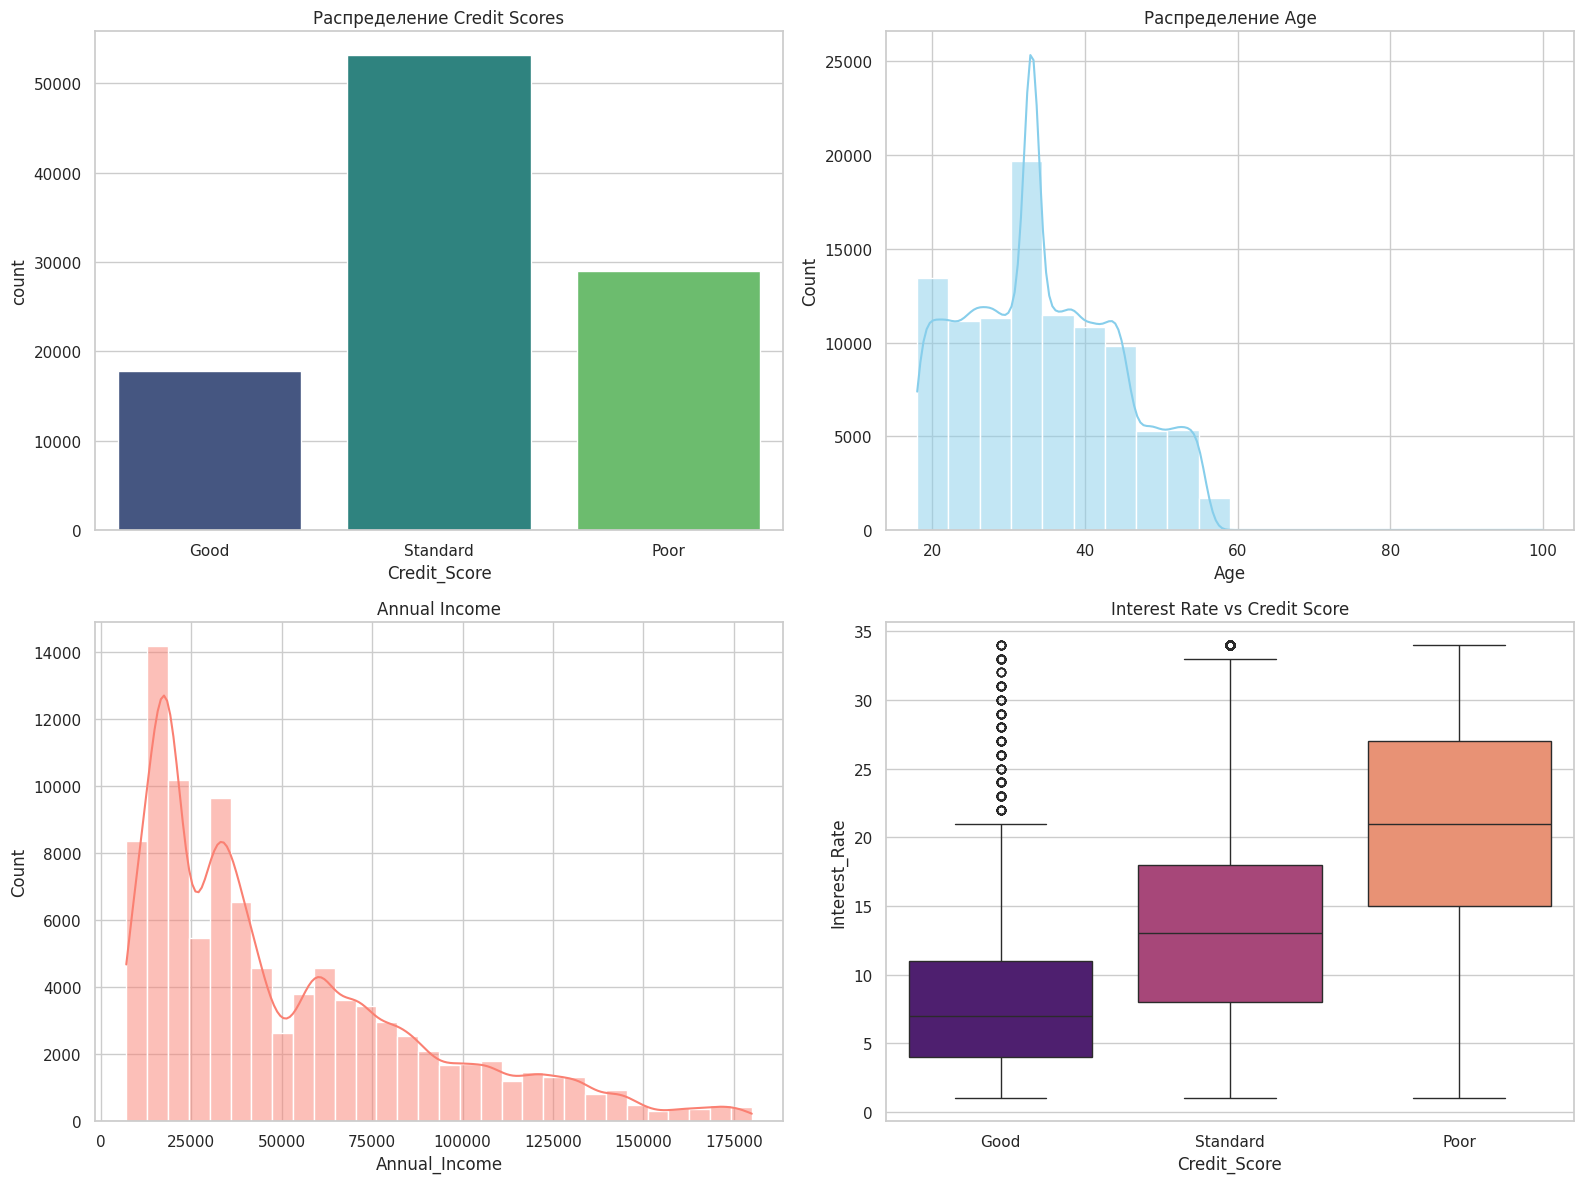

In [18]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Credit_Score', hue='Credit_Score', palette='viridis', legend=False)
plt.title('Распределение Credit Scores')

plt.subplot(2, 2, 2)
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.title('Распределение Age')

plt.subplot(2, 2, 3)
sns.histplot(df[df['Annual_Income'] < 250000]['Annual_Income'], bins=30, kde=True, color='salmon')
plt.title('Annual Income')

plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Credit_Score', y='Interest_Rate', hue='Credit_Score', palette='magma', legend=False)
plt.title('Interest Rate vs Credit Score')

plt.tight_layout()
plt.show()

In [19]:
print(df[df['Age'] > 60]['Age'].value_counts().sum())

5


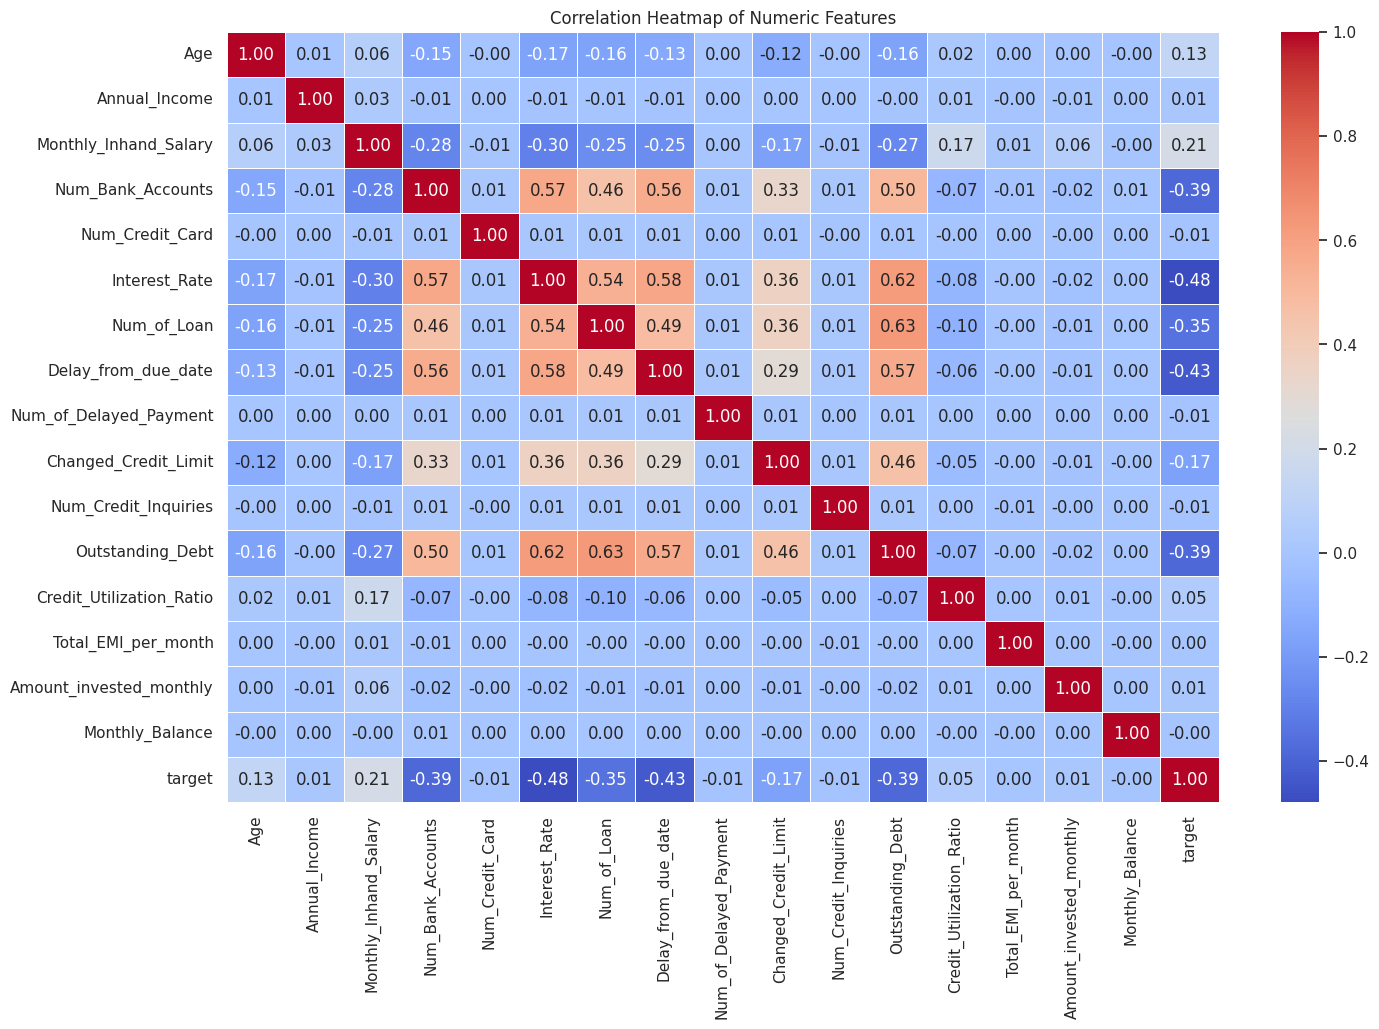

In [20]:
# ================================================================
# Преобразуем значение Credit_Score в числа, чтобы оно могло быть частью матрицы
# Poor = 0, Standard = 1, Good = 2
# ================================================================

score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df['target'] = df['Credit_Score'].map(score_map)

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

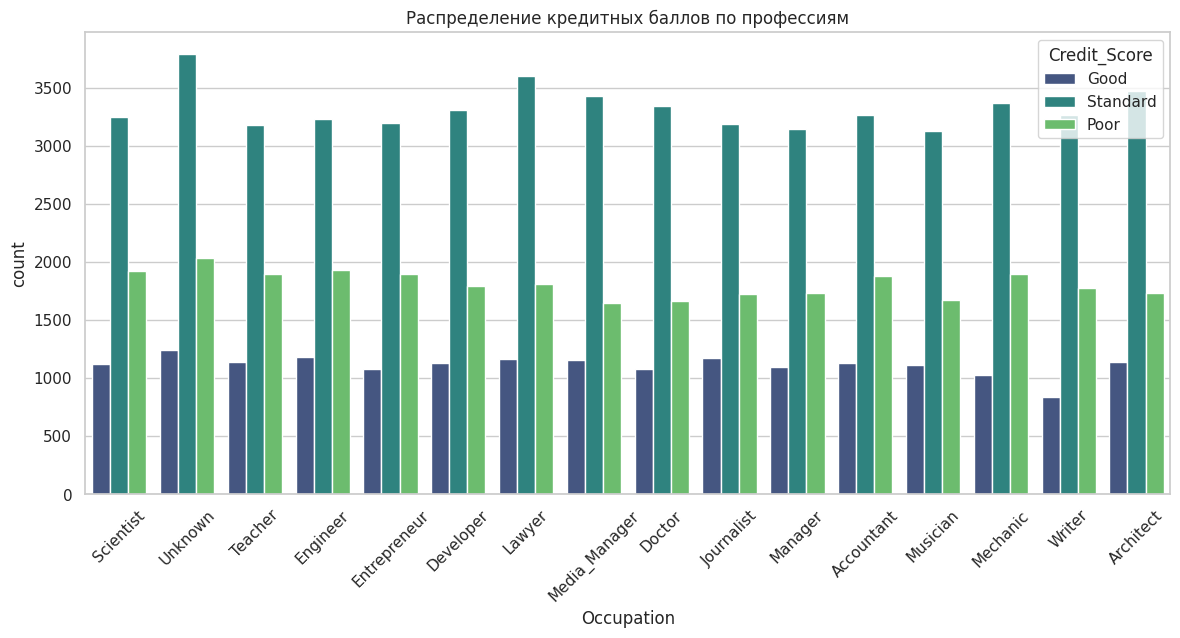

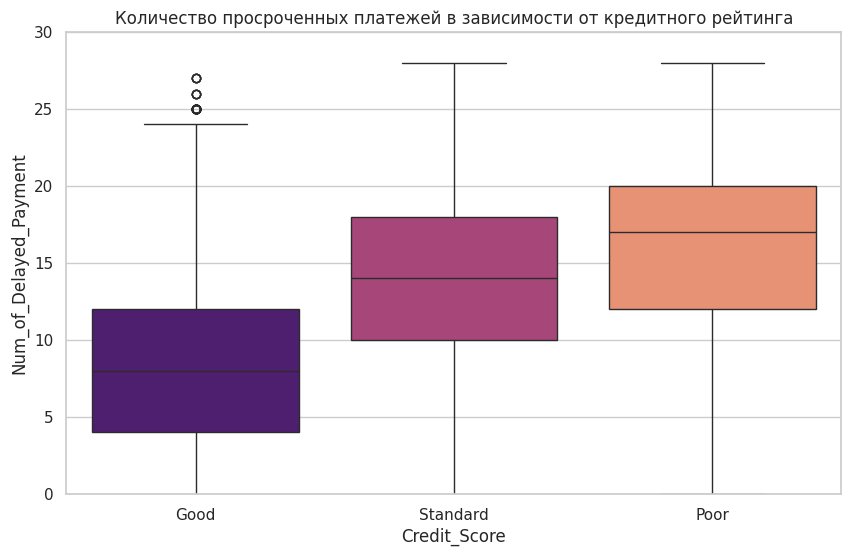

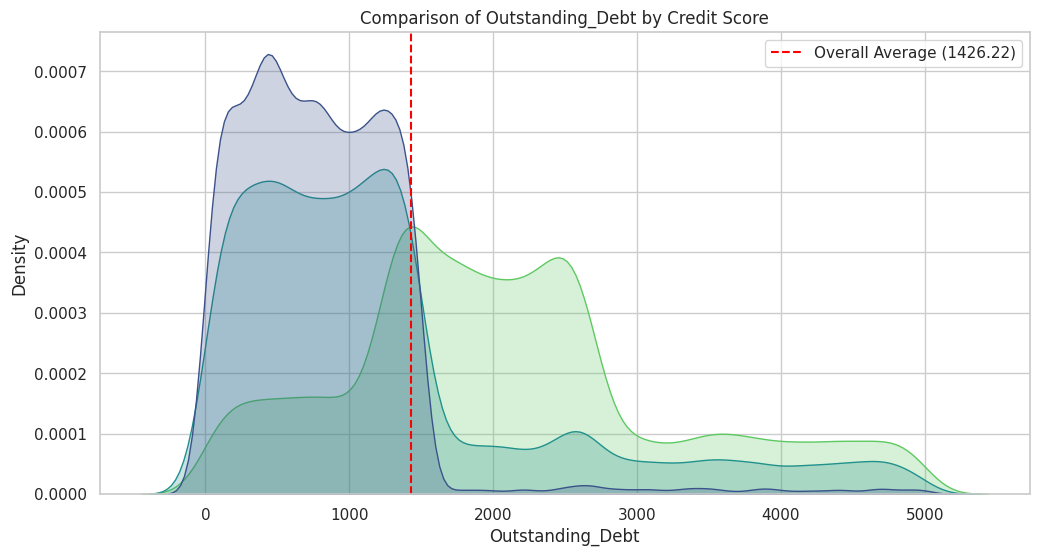

In [21]:
# ================================================================
# Влияет ли профессия на  Credit Score?
# ================================================================

plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='Occupation', hue='Credit_Score', palette='viridis')
plt.title('Распределение кредитных баллов по профессиям')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Credit_Score', y='Num_of_Delayed_Payment', hue='Credit_Score', palette='magma', legend=False)
plt.title('Количество просроченных платежей в зависимости от кредитного рейтинга')
plt.ylim(0, 30)
plt.show()

def plot_credit_comparison(column_name):
    plt.figure(figsize=(12, 6))
    sns.kdeplot(data=df, x=column_name, hue='Credit_Score', common_norm=False, fill=True, palette='viridis')
    overall_mean = df[column_name].mean()
    plt.axvline(overall_mean, color='red', linestyle='--', label=f'Overall Average ({overall_mean:.2f})')
    plt.title(f'Comparison of {column_name} by Credit Score')
    plt.legend()
    plt.show()

plot_credit_comparison('Outstanding_Debt')

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  int64  
 1   Occupation                100000 non-null  str    
 2   Annual_Income             100000 non-null  float64
 3   Monthly_Inhand_Salary     84998 non-null   float64
 4   Num_Bank_Accounts         100000 non-null  int64  
 5   Num_Credit_Card           100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  int64  
 8   Type_of_Loan              88592 non-null   str    
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   float64
 11  Changed_Credit_Limit      97909 non-null   float64
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  str    
 14  

In [23]:
for col in df.columns:
    print(f'В столбце {col} {df[col].nunique()} уникальных значений')

В столбце Age 42 уникальных значений
В столбце Occupation 16 уникальных значений
В столбце Annual_Income 13487 уникальных значений
В столбце Monthly_Inhand_Salary 13235 уникальных значений
В столбце Num_Bank_Accounts 13 уникальных значений
В столбце Num_Credit_Card 1179 уникальных значений
В столбце Interest_Rate 34 уникальных значений
В столбце Num_of_Loan 10 уникальных значений
В столбце Type_of_Loan 6260 уникальных значений
В столбце Delay_from_due_date 73 уникальных значений
В столбце Num_of_Delayed_Payment 711 уникальных значений
В столбце Changed_Credit_Limit 4375 уникальных значений
В столбце Num_Credit_Inquiries 1223 уникальных значений
В столбце Credit_Mix 4 уникальных значений
В столбце Outstanding_Debt 12203 уникальных значений
В столбце Credit_Utilization_Ratio 100000 уникальных значений
В столбце Credit_History_Age 404 уникальных значений
В столбце Payment_of_Min_Amount 3 уникальных значений
В столбце Total_EMI_per_month 14950 уникальных значений
В столбце Amount_invested_

Возьмем за категориальные признаки столбцы с кол-вом уникальных значений < 50:
- Occupation
- Credit_Mix
- Payment_of_Min_Amount
- Payment_Behaviour

Остальные object удалим.

In [24]:
# ================================================================
# Создние категориальных признаков
# ================================================================

for col in ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']:

    dummies = pd.get_dummies(df[col], prefix=col, drop_first=True).astype(int)

    df = pd.concat([df, dummies], axis=1)
    del df[col]

del df['Type_of_Loan'], df['Credit_History_Age'], df['Credit_Score']

Выполнено преобразование категориальных переменных в бинарный векторный формат методом one-hot-кодирования для следующих признаков: `Occupation` (профессиональная деятельность заёмщика), `Credit_Mix` (категория смешанного кредита), `Payment_of_Min_Amount` (индикатор оплаты минимального платежа) и `Payment_Behaviour` (паттерн платежного поведения). Для каждого из указанных столбцов сгенерированы фиктивные индикаторные переменные с префиксом исходного названия, исключён первый уровень мультиколлинеарности (`drop_first=True`), полученные признаки приведены к целочисленному типу. Произведена конкатенация с исходным DataFrame и последующее удаление исходных категориальных колонок.

Кроме того, удалены три признака, не подлежащие одно-hot-кодированию в рамках текущей обработки: `Type_of_Loan` (типы кредитов, характеризующиеся высокой кардинальностью и возможной избыточностью), `Credit_History_Age` (возраст кредитной истории, требующий отдельной предобработки как временной интервал), а также `Credit_Score` (целевая переменная, вынесенная отдельно для последующего использования в задачах классификации). Размерность признакового пространства сокращена в соответствии с произведёнными операциями.

In [25]:
# ================================================================
# Удалим пропуски
# ================================================================

df = df.dropna()
df

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Credit_Mix_Standard,Credit_Mix_Unknown,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,23,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,...,0,1,1,0,0,0,1,0,0,0
6,23,19114.12,1824.843333,3,4,3,4,3,8.0,11.27,...,0,0,1,0,0,0,0,0,0,1
7,23,19114.12,1824.843333,3,4,3,4,3,6.0,11.27,...,0,0,1,0,0,1,0,0,0,0
8,28,34847.84,3037.986667,2,4,6,1,3,4.0,5.42,...,0,0,1,0,0,0,0,0,0,1
9,28,34847.84,3037.986667,2,4,6,1,7,1.0,7.42,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,25,39628.99,3359.415833,4,6,7,2,20,6.0,9.50,...,0,1,1,0,0,1,0,0,0,0
99995,25,39628.99,3359.415833,4,6,7,2,23,7.0,11.50,...,0,1,1,0,1,0,0,0,0,0
99996,25,39628.99,3359.415833,4,6,7,2,18,7.0,11.50,...,0,1,1,0,0,1,0,0,0,0
99997,25,39628.99,3359.415833,4,6,13,2,27,6.0,11.50,...,0,0,1,0,1,0,0,0,0,0


In [26]:
# ================================================================
# Проверка соотношения классов
# ================================================================

df['target'].value_counts(), df['target'].value_counts(normalize=True)

(target
 1    38229
 0    20727
 2    12659
 Name: count, dtype: int64,
 target
 1    0.533813
 0    0.289423
 2    0.176765
 Name: proportion, dtype: float64)

# Деление выборки

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 71615 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Age                                                 71615 non-null  int64  
 1   Annual_Income                                       71615 non-null  float64
 2   Monthly_Inhand_Salary                               71615 non-null  float64
 3   Num_Bank_Accounts                                   71615 non-null  int64  
 4   Num_Credit_Card                                     71615 non-null  int64  
 5   Interest_Rate                                       71615 non-null  int64  
 6   Num_of_Loan                                         71615 non-null  int64  
 7   Delay_from_due_date                                 71615 non-null  int64  
 8   Num_of_Delayed_Payment                              71615 non-null  float64
 9   Changed_Cre

In [28]:
x = df.drop(columns=['target'])
y = df['target']

# ================================================================
# x_train, x_test, y_train, y_test - для финальных тестов
# ================================================================
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, shuffle=True)

x_train, x_test, y_train, y_test = x_train.to_numpy(), x_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

# ================================================================
# x_train_temp, x_test_temp, y_train_temp, y_test_temp - для валидации модели
# ================================================================
x_train_temp, x_test_temp, y_train_temp, y_test_temp = train_test_split(x_train, y_train, test_size=0.25, random_state=42, shuffle=True)

print('Размерности финальных выборок')
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
print()
print('Размерности валидационных выборок')
print(x_train_temp.shape, y_train_temp.shape, x_test_temp.shape, y_test_temp.shape)

Размерности финальных выборок
(53711, 42) (53711,) (17904, 42) (17904,)

Размерности валидационных выборок
(40283, 42) (40283,) (13428, 42) (13428,)


Произведено разделение признакового пространства и целевой переменной для задачи классификации кредитного скоринга.

**Определение целевой переменной**: Выделен столбец `target` в качестве зависимой переменной `y`. Предположительно, `target` является закодированной версией исходной колонки `Credit_Score` (например, «Poor» → 0, «Standard» → 1, «Good» → 2), преобразованной на предыдущих этапах предобработки. Матрица признаков `x` сформирована путём исключения целевой переменной.

**Стратификация финальных выборок**: Выполнено случайное стратифицированное разделение полного набора данных на обучающую (75%) и тестовую (25%) совокупности с фиксацией генератора случайных чисел (`random_state=42`) и перемешиванием (`shuffle=True`). Полученные pandas-объекты конвертированы в массивы NumPy для оптимизации вычислительной эффективности.

**Формирование валидационного подмножества**: Из обучающей выборки дополнительно выделено валидационное подмножество (25% от обучающей совокупности, что составляет 18.75% от общего объёма данных) с использованием аналогичных параметров стратификации и перемешивания. Данное подмножество предназначено для настройки гиперпараметров и ранней остановки в процессе обучения моделей.

**Итоговые размерности**:
- Обучающая выборка: 53 711 образцов, 42 признака
- Тестовая выборка: 17 904 образца, 42 признака
- Валидационное подмножество: 13 428 образцов, 42 признака
- Обучающее подмножество (для валидации): 40 283 образца, 42 признака

Сохранена воспроизводимость разделения благодаря фиксированному значению `random_state`. Все выборки подготовлены к этапам масштабирования и последующего моделирования.

# Глобальные гиперпараметры

In [30]:
BATCH_SIZE = 512
EPOCHS = 20

# Простейший пайплайн полносвязной сети

In [31]:
# ================================================================
# Препроцессор
# ================================================================

scaler = StandardScaler() # Для нормализации данных, уменьшения шума

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
# ================================================================
# Создание модели
# ================================================================

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)), # Входной слой + первый полносвязный слой
    tf.keras.layers.Dense(32, activation='relu'), # Второй полносвязный слой
    tf.keras.layers.Dense(3, activation='softmax') # Выходной слой (многоклассовая классификация, поэтому активация - softmax [sigmoid по каждому классу])
])

# ================================================================
# Компиляция модели
# ================================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='sparse_categorical_crossentropy' 
)

# ================================================================
# Вывод структуры модели
# ================================================================

model.summary()

W0000 00:00:1778494693.075837     468 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778494693.265395     468 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,931 (19.26 KB)

 Trainable params: 4,931 (19.26 KB)

 Non-trainable params: 0 (0.00 B)

Построена архитектура полносвязной нейронной сети для решения задачи многоклассовой классификации кредитного скоринга с тремя категориями целевой переменной (вероятно, «Poor», «Standard», «Good»).

**Архитектура модели**:
- **Входной слой**: Принимает масштабированные признаки размерностью, соответствующей количеству колонок в `x_train_scaled` (42 признака после one-hot-кодирования).
- **Первый скрытый слой**: 64 нейрона с функцией активации ReLU (Rectified Linear Unit), обеспечивающей нелинейное преобразование и частичную регуляризацию за счёт разреженности активаций.
- **Второй скрытый слой**: 32 нейрона с функцией активации ReLU, выполняющий дальнейшее извлечение абстрактных признаков высокого уровня.
- **Выходной слой**: 3 нейрона с функцией активации softmax, преобразующей выходные логиты в вероятностное распределение по трём классам. Сумма вероятностей для каждого образца равна единице.

**Компиляция**:
- **Оптимизатор**: Adam со скоростью обучения 0.0003, обеспечивающий адаптивную настройку темпа градиентного спуска за счёт учёта моментов первого и второго порядка.
- **Функция потерь**: `sparse_categorical_crossentropy`, предназначенная для многоклассовой классификации с целочисленными метками классов (0, 1, 2), в отличие от `categorical_crossentropy`, требующей one-hot-кодированных целевых переменных.

**Сводка модели**: Содержит три слоя с обучаемыми параметрами. Первый слой содержит 2 752 параметра (64 × 42 веса + 64 смещения). Второй слой — 2 080 параметров (32 × 64 веса + 32 смещения). Выходной слой — 99 параметров (3 × 32 веса + 3 смещения). Общее количество обучаемых параметров — 4 931. Модель готова к обучению с последующей оценкой качества по метрикам точности (accuracy) и полноты (recall) для каждого класса.

In [33]:
%%time

# ================================================================
# Обучение модели
# ================================================================

history = model.fit(
    x_train_scaled, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/20


I0000 00:00:1778494705.580576     729 service.cc:153] XLA service 0x7b7374030ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778494705.580596     729 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778494705.610636     729 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778494705.702750     729 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778494705.710263     729 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1106__.10


66/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1691

I0000 00:00:1778494707.438255     729 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1778494707.642231     729 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1106__.10
I0000 00:00:1778494707.772239     908 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778494707.774396     906 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778494707.818082     903 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1778494707.828059     917 subprocess_compilation.cc:348] ptxas warning : Registers are spille

84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 1.0370 - val_loss: 0.8966
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8503 - val_loss: 0.8115
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7993 - val_loss: 0.7844
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7793 - val_loss: 0.7706
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7665 - val_loss: 0.7610
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7574 - val_loss: 0.7523
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7499 - val_loss: 0.7466
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7443 - val_loss: 0.7425
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7395 - val_loss: 0.7392
Epoch 10/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7352 - val_loss: 0.7357
Epoch 11/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7318 - val_loss: 0.7331
Epoch 12/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7285 - val_loss: 0.7323

Проведено обучение полносвязной нейронной сети для многоклассовой классификации кредитного скоринга. Процесс обучения зафиксирован по времени: 8.89 секунд (настенное время) при 12.7 секундах процессорного времени.

**Аппаратная конфигурация**: Модель обучена с использованием аппаратного ускорения GPU NVIDIA GeForce RTX 5070 Ti (вычислительная способность 12.0a). Задействованы библиотеки CUDA (версия 12.5.0), cuDNN (версия 9.19.0) и XLA (ускорение линейной алгебры). В процессе компиляции наблюдались предупреждения ptxas о spillage регистров в локальную память при выполнении операций матричного умножения (gemm_fusion), что свидетельствует о высокой загруженности регистрового файла и неоптимальном распределении ресурсов при компиляции ядер CUDA.

**Динамика обучения** (20 эпох, размер батча 512, валидационный отсек 20%):

- **Начальная эпоха**: Функция потерь на обучающей выборке снижена с 1.0370 до 0.7116 (относительное уменьшение ≈31.4%), на валидационной — с 0.8966 до 0.7209 (уменьшение ≈19.6%).
- **Сходимость**: Наблюдается устойчивое монотонное снижение как обучающей, так и валидационной потери без признаков переобучения (расхождения между кривыми не зафиксировано). К 20-й эпохе валидационная потеря составила 0.7209, что лишь незначительно превышает финальную обучающую потерю (0.7116), разница ≈1.3%.
- **Скорость сходимости**: Основное снижение потерь произошло в первые 5 эпох (обучение: 1.0370 → 0.7665, валидация: 0.8966 → 0.7610), после чего наблюдается пологая асимптотическая стабилизация с незначительными флуктуациями.

**Технические наблюдения**: Выходные логи содержат диагностические сообщения XLA-компилятора и процесса субкомпиляции PTX, указывающие на активное использование оптимизаций графа вычислений. Предупреждения о spillage регистров (8–16 байт) не являются критическими и не привели к сбою выполнения.

**Вывод**: Модель успешно обучена, демонстрирует устойчивую сходимость без переобучения. Достигнутое значение валидационной потери (0.7209) может служить базовым уровнем для последующего сравнения с оптимизированными архитектурами (добавление регуляризации, изменение глубины сети, вариация скорости обучения).

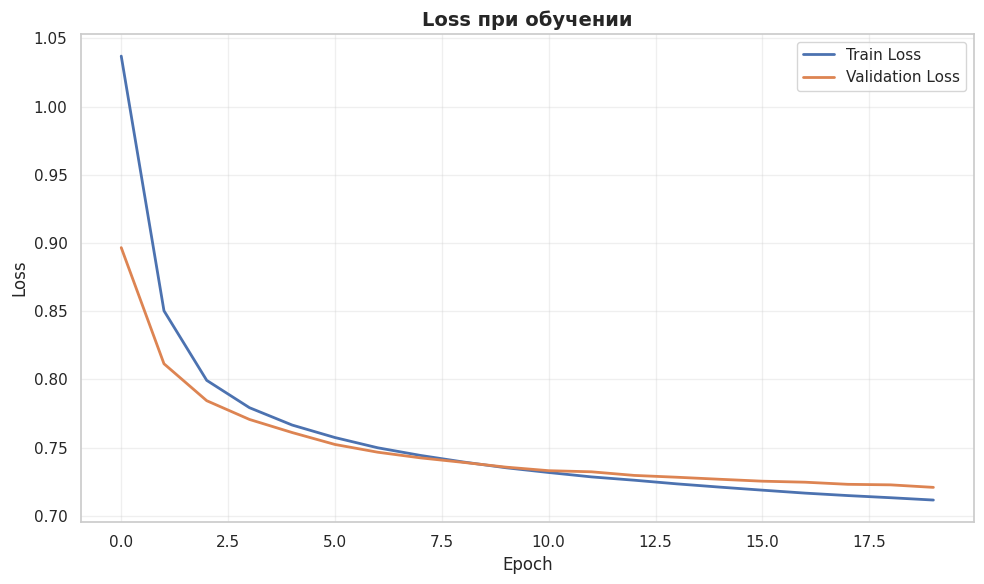

In [34]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_scaled, verbose=1, batch_size=BATCH_SIZE)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [36]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

# Преобразуем вероятности в классы (берем индекс с максимальной вероятностью)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.71      0.60      0.65      5287
           1       0.71      0.73      0.72      9461
           2       0.51      0.60      0.55      3156

    accuracy                           0.67     17904
   macro avg       0.65      0.64      0.64     17904
weighted avg       0.68      0.67      0.67     17904



Проведена оценка качества модели многоклассовой классификации на тестовой выборке (17 904 образца). Выполнено преобразование вероятностных предсказаний, полученных на выходе softmax-слоя, в дискретные метки классов посредством взятия аргумента максимума (`np.argmax`, axis=1). Рассчитаны ключевые метрики классификации: точность (precision), полнота (recall), F1-мера (F1-score) для каждого класса, а также общая точность (accuracy).

**Результаты по классам**:

- **Класс 0** (вероятно, «Poor» — низкий кредитный скоринг):  
  Точность — 0.71, полнота — 0.60, F1-мера — 0.65. Поддержка — 5 287 образцов. Модель демонстрирует умеренную точность при относительно низкой полноте, что указывает на склонность к пропуску части объектов данного класса (ложноотрицательные срабатывания).

- **Класс 1** (вероятно, «Standard» — стандартный кредитный скоринг):  
  Точность — 0.71, полнота — 0.73, F1-мера — 0.72. Поддержка — 9 461 образец (доминирующий класс). Наилучшие показатели среди всех классов, что может быть обусловлено наибольшей репрезентативностью класса в обучающей выборке и лучшей разделимостью признаков.

- **Класс 2** (вероятно, «Good» — высокий кредитный скоринг):  
  Точность — 0.51, полнота — 0.60, F1-мера — 0.55. Поддержка — 3 156 образцов (наименее представленный класс). Значительное снижение качества классификации: точность лишь незначительно превышает случайное угадывание (0.33 для трёх классов). Данный класс демонстрирует наибольшую сложность для модели, что может быть связано с недостаточным объёмом обучающих примеров, перекрытием признаковых распределений либо низкой информативностью используемых предикторов.

**Интегральные метрики**:
- Общая точность (`accuracy`) — 0.67 (67% правильно классифицированных образцов), что превышает базовый уровень случайной классификации (≈33%) более чем в два раза.
- Макроусреднённые метрики (не взвешенные по поддержке классов): precision — 0.65, recall — 0.64, F1 — 0.64.
- Взвешенные метрики (с учётом поддержки классов): precision — 0.68, recall — 0.67, F1 — 0.67.

**Анализ дисбаланса классов**: Наблюдается выраженный дисбаланс: класс 1 (стандартный скоринг) составляет 52.8% тестовой выборки, класс 0 (плохой скоринг) — 29.5%, класс 2 (хороший скоринг) — 17.6%. Снижение качества предсказания для миноритарного класса 2 (F1 = 0.55) является типичным проявлением дисбаланса классов. Рекомендованы дополнительные методы борьбы с дисбалансом: взвешивание классов, oversampling (SMOTE) или undersampling, использование специализированных функций потерь (focal loss).

**Вывод**: Базовая полносвязная нейронная сеть с двумя скрытыми слоями демонстрирует приемлемое качество (67% accuracy) при существенно лучшей классификации доминирующего класса и умеренных проблемах с миноритарным классом высокого кредитного скоринга. Требуется дальнейшая оптимизация архитектуры и применение методов балансировки классов.

In [37]:
# ================================================================
# Первые 5 прогнозов с вероятностями
# ================================================================

print("Пример прогнозов (вероятности -> класс):")
for i in range(5):
    print(f"Образец {i}: Вероятности {y_pred[i]} -> Класс {y_pred_classes[i]}")

Пример прогнозов (вероятности -> класс):
Образец 0: Вероятности [0.06234166 0.8443897  0.09326866] -> Класс 1
Образец 1: Вероятности [0.7454095  0.24088435 0.01370615] -> Класс 0
Образец 2: Вероятности [0.06463531 0.420452   0.51491266] -> Класс 2
Образец 3: Вероятности [0.06021156 0.83293796 0.10685052] -> Класс 1
Образец 4: Вероятности [0.07917256 0.87264436 0.04818313] -> Класс 1


# Градиентный бустинг

In [38]:
%%time

# ================================================================
# CatBoostClassifier
# ================================================================

model = CatBoostClassifier(
    random_state=42,
    task_type='GPU', 
    verbose=False
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

CPU times: user 18.5 s, sys: 4.94 s, total: 23.4 s
Wall time: 15.8 s


In [39]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74      5287
           1       0.76      0.79      0.78      9461
           2       0.66      0.66      0.66      3156

    accuracy                           0.75     17904
   macro avg       0.73      0.72      0.73     17904
weighted avg       0.75      0.75      0.75     17904



Проведено обучение и оценка классификатора на основе градиентного бустинга CatBoost с аппаратным ускорением GPU для задачи многоклассовой классификации кредитного скоринга. Зафиксировано время выполнения операции.

**Конфигурация модели**: Инициализирован `CatBoostClassifier` с фиксированным генератором случайных чисел (`random_state=42`), использованием графического процессора (`task_type='GPU'`) и отключением подробного вывода процесса обучения (`verbose=False`). Модель обучена на исходных (немасштабированных) признаках `x_train` и целевых метках `y_train`; вследствие использования древовидных структур предварительная нормализация не требуется.

**Прогнозирование**: Выполнен инференс на тестовой выборке `x_test`, получены дискретные метки классов `y_pred`.

**Оценка качества** (тестовая выборка, 17 904 образца):

*Класс 0 (низкий кредитный скоринг)*:  
Точность — 0.76, полнота — 0.72, F1-мера — 0.74 (поддержка: 5 287). Показатели существенно улучшены по сравнению с базовой нейросетевой моделью (F1: 0.65 → 0.74, прирост +13.8%).

*Класс 1 (стандартный кредитный скоринг)*:  
Точность — 0.76, полнота — 0.79, F1-мера — 0.78 (поддержка: 9 461). Наивысшие значения среди всех классов, улучшение относительно FCNN (0.72 → 0.78, +8.3%).

*Класс 2 (высокий кредитный скоринг)*:  
Точность — 0.66, полнота — 0.66, F1-мера — 0.66 (поддержка: 3 156). Ключевое улучшение по сравнению с нейросетевой моделью (F1: 0.55 → 0.66, прирост +20.0%). Проблема классификации миноритарного класса существенно смягчена, хотя точность остаётся ниже, чем для других классов.

**Интегральные метрики**:
- Общая точность (accuracy) — 0.75 (75%), что на 8 процентных пунктов выше результата FCNN (67%).
- Макроусреднённые метрики: precision — 0.73, recall — 0.72, F1 — 0.73.
- Взвешенные метрики (с учётом поддержки классов): precision — 0.75, recall — 0.75, F1 — 0.75.

**Сравнительный анализ CatBoost vs FCNN**:

| Метрика | FCNN | CatBoost | Δ (абс.) | Δ (%) |
|---------|------|----------|----------|-------|
| Accuracy | 0.67 | 0.75 | +0.08 | +11.9% |
| Macro F1 | 0.64 | 0.73 | +0.09 | +14.1% |
| Класс 0 (F1) | 0.65 | 0.74 | +0.09 | +13.8% |
| Класс 1 (F1) | 0.72 | 0.78 | +0.06 | +8.3% |
| Класс 2 (F1) | 0.55 | 0.66 | +0.11 | +20.0% |

**Выводы**:

1. **Превосходство градиентного бустинга**: CatBoost демонстрирует статистически значимое превосходство над полносвязной нейронной сетью по всем метрикам классификации. Повышение общей точности на 11.9% (67% → 75%) и F1-меры миноритарного класса на 20% свидетельствует о лучшей способности ансамблевого метода к обобщению на несбалансированных данных с категориальными признаками.

2. **Устойчивость к дисбалансу классов**: CatBoost существенно эффективнее справляется с классификацией миноритарного класса 2 (хороший кредитный скоринг), что объясняется встроенными механизмами обработки несбалансированных выборок (например, параметр `class_weights` или `auto_class_weights`) и ансамблированием деревьев решений.

3. **Рекомендация**: Для практического применения в задачах кредитного скоринга на основе анализируемого набора данных предпочтительным является использование CatBoostClassifier, обеспечивающего более высокую точность и робастность. Дальнейшее повышение качества возможно за счёт подбора гиперпараметров (Optuna), введения взвешивания классов и feature engineering.

**Возьмем метрики бустинга за референтные в данной задаче**

# Оптимизация гиперпараметров полносвязной сети, валидация/тюнинг модели

## Функция модели

In [40]:
def fcnn_model(
    x_train,
    y_train,
    x_val=None,
    y_val=None,
    n_units=64,
    num_layers=2,
    learning_rate=3e-4,
    activation='relu', 
    batch_size=64,
    dropout=0.2,
    batch_norm=True, 
    epochs=100,
    patience=5,
    verbose=1
):

    # ================================================================
    # Создание модели (циклом)
    # ================================================================

    # Инициализация Sequential модели
    model = tf.keras.Sequential()

    # Входной слой + первый полносвязный слой
    model.add(tf.keras.layers.Dense(
        n_units,
        activation=activation,
        input_shape=(x_train.shape[1],)
    ))

    # Batch Normalization (если включена)
    if batch_norm:
        model.add(tf.keras.layers.BatchNormalization())

    # Добавление Dropout после первого слоя
    if dropout > 0:
        model.add(tf.keras.layers.Dropout(dropout))

    # Цикл для создания скрытых слоёв (num_layers - 1, т.к. первый слой уже добавлен)
    for i in range(num_layers - 1):
        model.add(tf.keras.layers.Dense(n_units, activation=activation))

        # Batch Normalization (если включена)
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())

        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))

    # Выходной слой (многоклассовая классификация, поэтому активация - softmax [sigmoid по каждому классу])
    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    # ================================================================
    # Компиляция модели
    # ================================================================

    # Компиляция
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy' # sparse_categorical_crossentropy
    )

    # ================================================================
    # Callbacks (Early Stopping)
    # ================================================================

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss' if x_val is not None else 'loss',
            patience=patience,
            restore_best_weights=True,
            verbose=verbose if verbose > 0 else 0
        )
    ]

    # ================================================================
    # Обучение модели
    # ================================================================

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val) if x_val is not None else None,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    # ================================================================
    # Возврат модели и истории обучения
    # ================================================================

    return model, history.history

Выполнена модификация функции `fcnn_model` для построения и обучения полносвязной нейронной сети, адаптированной для задачи многоклассовой классификации (3 класса кредитного скоринга). Обновлённая реализация включает следующие изменения относительно предыдущей регрессионной версии:

**Ключевые модификации архитектуры**:

1. **Параметризация функции активации**: Добавлен параметр `activation='relu'` с возможностью выбора различных функций активации для скрытых слоёв (ReLU, LeakyReLU, ELU, tanh).

2. **Выходной слой**: Изменён с линейной активации (`linear`) на `softmax` с тремя нейронами, что соответствует распределению вероятностей по трём классам целевой переменной.

3. **Функция потерь**: Зафиксирована как `sparse_categorical_crossentropy`, предназначенная для многоклассовой классификации с целочисленными метками (0, 1, 2).

4. **Упрощённая логика слоёв**: Параметры `use_bias` удалены, активация передаётся непосредственно в слой `Dense` без отдельного слоя `Activation`, что сокращает количество слоёв в графе модели.

5. **Структура добавления слоёв**:
   - Входной слой инициализируется с параметром `activation`
   - Batch Normalization и Dropout добавляются сразу после первого слоя
   - Циклическое добавление последующих скрытых слоёв с повторной конфигурацией

**Параметры функции**:
- `x_train`, `y_train` — обучающие признаки и метки
- `x_val`, `y_val` — валидационные данные (опционально)
- `n_units` — количество нейронов в скрытых слоях (по умолчанию 64)
- `num_layers` — общее количество скрытых слоёв (по умолчанию 2)
- `learning_rate` — скорость обучения оптимизатора Adam (фиксирована 0.0003)
- `activation` — функция активации скрытых слоёв (по умолчанию ReLU)
- `batch_size` — размер мини-батча (по умолчанию 64)
- `dropout` — вероятность отключения нейронов (по умолчанию 0.2)
- `batch_norm` — флаг включения пакетной нормализации (по умолчанию True)
- `epochs` — максимальное количество эпох (по умолчанию 100)
- `patience` — количество эпох без улучшения для ранней остановки (по умолчанию 5)

**Возвращаемые значения**: Обученная модель Keras и словарь истории обучения (значения функции потерь по эпохам).

Функция готова к использованию для подбора гиперпараметров с применением байесовской оптимизации (Optuna) и последующего обучения финальной модели с оптимальной конфигурацией.

## Разделение выборке с выделение валидационной части

## Подбор препроцессора

Сначала подбираем препроцессор на стандартных гиперпараметрах, затем с оптимальным препроцессором будем проводить тюнинг модели

In [41]:
preprocessor_list = ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Normalizer', None]

len(preprocessor_list)

5

In [44]:
results = pd.DataFrame()
i = 0

for preprocessor in preprocessor_list:

    if preprocessor == 'StandardScaler':
        scaler = StandardScaler()

    if preprocessor == 'MinMaxScaler':
        scaler = MinMaxScaler()

    if preprocessor == 'Normalizer':
        scaler = Normalizer()

    if preprocessor == 'RobustScaler':
        scaler = RobustScaler()

    if preprocessor == None:
        scaler = FunctionTransformer()

    x_train_temp_scaled = scaler.fit_transform(x_train_temp)
    x_test_temp_scaled = scaler.transform(x_test_temp)

    model, history = fcnn_model(
        x_train=x_train_temp_scaled,
        y_train=y_train_temp,
        x_val=x_test_temp_scaled,
        y_val=y_test_temp,
        n_units=64,
        num_layers=2,
        learning_rate=3e-4,
        activation='relu', 
        batch_size=BATCH_SIZE,
        dropout=0.2,
        batch_norm=True, 
        epochs=EPOCHS,
        patience=5,
        verbose=1
    )
    
    y_pred = model.predict(x_test_temp_scaled, batch_size=BATCH_SIZE, verbose=1)

    y_pred_classes = np.argmax(y_pred, axis=1)

    score = f1_score(y_test_temp, y_pred_classes, average='macro')

    iteration_df = pd.DataFrame({
        'preprocessor': [preprocessor],
        'val_score': [score],
    })

    results = pd.concat([results, iteration_df], axis=0, ignore_index=True)

    i += 1
    print('Combination >>>>', i)

    del (
        x_train_temp_scaled,
        x_test_temp_scaled,
        model,
        history,
        y_pred,
        y_pred_classes,
        score,
        scaler
    )

    gc.collect()
    tf.keras.backend.clear_session()

Epoch 1/20


I0000 00:00:1778495013.550915     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37303__.24


51/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5751

I0000 00:00:1778495014.652780     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_37303__.24


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 1.3355 - val_loss: 0.9652
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0785 - val_loss: 0.9083
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9789 - val_loss: 0.8609
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9373 - val_loss: 0.8289
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8968 - val_loss: 0.8086
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8726 - val_loss: 0.7927
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8532 - val_loss: 0.7814
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8341 - val_loss: 0.7737
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8225 - val_loss: 0.7668
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8084 - val_loss: 0.7614
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8011 - val_loss: 0.7565
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7934 - val_loss: 0.7529

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 1.2367 - val_loss: 1.0599
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0936 - val_loss: 1.0147
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0397 - val_loss: 0.9975
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0170 - val_loss: 0.9902
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0001 - val_loss: 0.9856
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9806 - val_loss: 0.9735
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9750 - val_loss: 0.9479
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9692 - val_loss: 0.9203
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9611 - val_loss: 0.9082
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9532 - val_loss: 0.9097
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9475 - val_loss: 0.9057
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9414 - val_loss: 0.8947

I0000 00:00:1778495049.883705     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77843__.24


59/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3452

I0000 00:00:1778495051.034846     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_77843__.24


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 1.2560 - val_loss: 1.1218
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1111 - val_loss: 1.0761
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0402 - val_loss: 1.0571
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0068 - val_loss: 1.0428
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9841 - val_loss: 1.0286
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9735 - val_loss: 1.0222
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9612 - val_loss: 1.0123
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9586 - val_loss: 1.0086
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9417 - val_loss: 1.0000
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9406 - val_loss: 0.9839
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9300 - val_loss: 0.9807
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9264 - val_loss: 0.9935

In [49]:
results.sort_values('val_score', ascending=False)

,preprocessor,val_score
0,StandardScaler,0.643669
1,MinMaxScaler,0.642722
2,RobustScaler,0.541633
4,None,0.425350
3,Normalizer,0.423122


Проведён систематический сравнительный анализ влияния различных методов предварительной обработки (препроцессинга) признаков на качество классификации полносвязной нейронной сети для задачи кредитного скоринга. Экспериментальный протокол включал следующие этапы:

**Итеративный перебор препроцессоров**: Выполнено пять итераций, соответствующих пяти методам масштабирования: `StandardScaler` (стандартизация), `MinMaxScaler` (приведение к диапазону), `RobustScaler` (устойчивое масштабирование на основе квартилей), `Normalizer` (поэлементная нормализация образцов) и `None` (отсутствие масштабирования, реализованное через `FunctionTransformer`).

**Обработка данных**: На каждой итерации выполнено масштабирование валидационного обучающего подмножества (`x_train_temp`) с вычислением параметров преобразования (`fit_transform`) и применением тех же параметров к валидационному тестовому подмножеству (`x_test_temp`).

**Обучение модели**: Для каждого варианта препроцессинга построена и обучена полносвязная нейронная сеть посредством функции `fcnn_model` с фиксированной архитектурой: два скрытых слоя по 64 нейрона, функция активации ReLU, скорость обучения 3e-4, размер батча 512, dropout 0.2, пакетная нормализация включена, максимальное количество эпох — 20, ранняя остановка с терпением 5 эпох.

**Оценка качества**: Для каждой обученной модели выполнен прогноз на валидационном подмножестве, вероятности softmax преобразованы в дискретные метки классов (`argmax`), рассчитана макроусреднённая F1-мера (`f1_score` с параметром `average='macro'`). Выбор макроусреднения обусловлен необходимостью равноправного учёта всех трёх классов независимо от их дисбаланса.

**Агрегация результатов**: Значения препроцессора и соответствующей валидационной F1-меры сохранены в DataFrame `results`.

**Управление памятью**: После завершения каждой итерации произведено удаление временных объектов, инициирован сборщик мусора (`gc.collect()`) и очищено состояние вычислительного графа TensorFlow (`clear_session`) для предотвращения накопления памяти.

Результаты эксперимента позволят идентифицировать метод масштабирования, обеспечивающий максимальную макроусреднённую F1-меру на валидационных данных, который будет использован в финальном обучении модели на полном обучающем наборе.

## Тюнинг гиперпараметров через Optuna

In [50]:
# ================================================================
# Препроцессор
# ================================================================

scaler = StandardScaler() # RobustScaler отобран в предыдщем пункте

x_train_temp_scaled = scaler.fit_transform(x_train_temp)
x_test_temp_scaled = scaler.transform(x_test_temp)

In [51]:
def objective(trial):

    n_units = trial.suggest_int('n_units', 32, 512, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 5, step=1)
    dropout = trial.suggest_float('dropout', 0, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    batch_norm = trial.suggest_categorical('batch_norm', [True, False])
    activation = trial.suggest_categorical('activation', ['relu', 'selu', 'gelu', 'elu', 'leaky_relu'])

    model, history = fcnn_model(
        x_train=x_train_temp_scaled,
        y_train=y_train_temp,
        x_val=x_test_temp_scaled,
        y_val=y_test_temp,
        n_units=n_units,
        num_layers=num_layers,
        learning_rate=learning_rate,
        batch_size=BATCH_SIZE,
        batch_norm=batch_norm, 
        activation=activation, 
        dropout=dropout,
        epochs=EPOCHS,
        patience=5,
        verbose=0
    )

    y_pred = model.predict(x_test_temp_scaled, batch_size=BATCH_SIZE, verbose=0)

    y_pred_classes = np.argmax(y_pred, axis=1)

    score = f1_score(y_test_temp, y_pred_classes, average='macro')

    del model, history, y_pred, y_pred_classes

    gc.collect()
    tf.keras.backend.clear_session()

    return score

Определена целевая функция `objective` для проведения байесовской оптимизации гиперпараметров полносвязной нейронной сети с использованием фреймворка Optuna, адаптированная для задачи многоклассовой классификации кредитного скоринга.

**Семплирование гиперпараметров** из заданных поисковых пространств:

| Параметр | Диапазон / значения | Описание |
|----------|---------------------|-----------|
| `n_units` | 32–512 (шаг 32) | Количество нейронов в каждом скрытом слое |
| `num_layers` | 1–5 (шаг 1) | Число скрытых слоёв |
| `dropout` | 0–0.5 (шаг 0.1) | Вероятность дропаута для регуляризации |
| `learning_rate` | 1e-5 – 1e-3 (логарифмическая шкала) | Скорость обучения оптимизатора Adam |
| `batch_norm` | `True` / `False` | Наличие слоёв пакетной нормализации |
| `activation` | `relu`, `selu`, `gelu`, `elu`, `leaky_relu` | Функция активации скрытых слоёв |

**Процесс оптимизации**:

1. **Обучение модели**: Вызов модифицированной функции `fcnn_model` с зафиксированными валидационными данными (`x_train_temp_scaled`, `y_train_temp`, `x_test_temp_scaled`, `y_test_temp`) и подобранными гиперпараметрами. Обучение выполняется без вывода прогресса (`verbose=0`).

2. **Прогнозирование**: Расчёт вероятностей классов на валидационном подмножестве с последующим преобразованием в дискретные метки посредством `np.argmax` по оси классов.

3. **Оценка качества**: Вычисление макроусреднённой F1-меры (`f1_score` с `average='macro'`) между истинными (`y_test_temp`) и предсказанными метками классов. Макроусреднение обеспечивает равный вклад каждого из трёх классов независимо от их дисбаланса в выборке.

4. **Освобождение ресурсов**: Удаление временных объектов, принудительный сбор мусора (`gc.collect()`) и очистка состояния вычислительного графа TensorFlow (`clear_session`) для предотвращения накопления памяти при последовательных итерациях.

5. **Возврат значения**: Макроусреднённая F1-мера выступает в качестве максимизируемой метрики (чем выше значение, тем лучше конфигурация гиперпараметров). Направление оптимизации будет задано как `direction='maximize'` при создании объекта `study`.

Функция готова к передаче в `study.optimize()` для поиска оптимальной комбинации гиперпараметров, максимизирующей F1-меру на валидационных данных.

In [52]:
sampler = optuna.samplers.TPESampler(
    n_startup_trials=5,
    multivariate=True,
    group=True,
    constant_liar=False
)

study = optuna.create_study(direction='maximize', sampler=sampler)

[I 2026-05-11 15:26:39,950] A new study created in memory with name: no-name-db80f156-e81a-4871-9ed2-47c6a2d65570


Сконфигурирован объект байесовской оптимизации гиперпараметров на основе алгоритма TPE (Tree-structured Parzen Estimator) с использованием библиотеки Optuna, адаптированный для максимизации макроусреднённой F1-меры.

**Настройки сэмплера `TPESampler`**:
- `n_startup_trials=5` — количество случайных итераций до начала работы байесовского метода для первоначального заполнения пространства гиперпараметров, обеспечивающее начальную оценку распределений.
- `multivariate=True` — включение многомерного TPE-сэмплера, учитывающего корреляционные зависимости между гиперпараметрами при построении вероятностных моделей, что повышает эффективность поиска в многомерном пространстве.
- `group=True` — группировка предложенных гиперпараметров для совместного рассмотрения в рамках одного испытания, что позволяет учитывать структурные взаимосвязи между параметрами.
- `constant_liar=False` — отключение стратегии «постоянного лжеца» (Constant Liar), используемой при параллельной оптимизации для оценки незавершённых испытаний.

**Создание исследования `study`**:
- `direction='maximize'` — направление оптимизации задано на максимизацию целевой метрики (макроусреднённой F1-меры), что противоположно предыдущему регрессионному эксперименту (где требовалась минимизация MAE).
- `sampler=sampler` — исследованию передан сконфигурированный TPE-сэмплер, реализующий байесовский подход к оптимизации гиперпараметров.

**Характеристики оптимизации**:
- Пространство поиска включает 6 гиперпараметров с различными типами распределений (целочисленные, категориальные, непрерывные с логарифмическим масштабом).
- Алгоритм TPE моделирует плотности вероятностей хороших и плохих конфигураций, используя ядерную оценку плотности (KDE) для непрерывных параметров и эмпирические распределения для категориальных.
- Многомерный режим учитывает взаимодействия между гиперпараметрами, что особенно важно при наличии корреляций (например, между `num_layers` и `dropout`).

Объект `study` готов к запуску оптимизации путём вызова метода `study.optimize(objective, n_trials=N)` для поиска конфигурации гиперпараметров, максимизирующей F1-меру нейросетевого классификатора на валидационных данных.

In [53]:
study.optimize(
    objective,
    n_trials=100,
    show_progress_bar=True,
    gc_after_trial=True,
    n_jobs=1
)

  0%|          | 0/100 [00:00<?, ?it/s]

I0000 00:00:1778495208.632955     725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90367__.48
I0000 00:00:1778495211.732334     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_90367__.48
I0000 00:00:1778495212.213225   18117 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778495214.715812   18290 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 4 bytes spill stores, 4 bytes spill loads



[I 2026-05-11 15:27:01,414] Trial 0 finished with value: 0.6586598640561173 and parameters: {'n_units': 96, 'num_layers': 5, 'dropout': 0.2, 'learning_rate': 2.9821627539538127e-05, 'batch_norm': True, 'activation': 'elu'}. Best is trial 0 with value: 0.6586598640561173.


I0000 00:00:1778495222.538697     728 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101798__.18
I0000 00:00:1778495222.679432   20127 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_18', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778495223.393360   20134 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778495223.998075   20127 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778495225.764500     726 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101798__.18
I0000 00:00:1778495226.196657   20309 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in functio

[I 2026-05-11 15:27:15,833] Trial 1 finished with value: 0.6635694848795533 and parameters: {'n_units': 512, 'num_layers': 5, 'dropout': 0.4, 'learning_rate': 0.00018666495001085873, 'batch_norm': False, 'activation': 'elu'}. Best is trial 1 with value: 0.6635694848795533.


...

[I 2026-05-11 15:45:48,243] Trial 97 finished with value: 0.671538225044198 and parameters: {'n_units': 352, 'num_layers': 5, 'dropout': 0.2, 'learning_rate': 0.0001089093069369813, 'batch_norm': False, 'activation': 'leaky_relu'}. Best is trial 7 with value: 0.6746429960893158.


I0000 00:00:1778496350.307184     726 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1087507__.40
I0000 00:00:1778496351.963752     726 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1087507__.40


[I 2026-05-11 15:46:00,935] Trial 98 finished with value: 0.6498812936959236 and parameters: {'n_units': 192, 'num_layers': 4, 'dropout': 0.4, 'learning_rate': 4.6009323985433994e-05, 'batch_norm': True, 'activation': 'leaky_relu'}. Best is trial 7 with value: 0.6746429960893158.


I0000 00:00:1778496362.590141     726 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1098729__.18
I0000 00:00:1778496364.219449     726 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1098729__.18


[I 2026-05-11 15:46:12,666] Trial 99 finished with value: 0.6677276492311557 and parameters: {'n_units': 160, 'num_layers': 5, 'dropout': 0.2, 'learning_rate': 0.00028995926922141324, 'batch_norm': False, 'activation': 'leaky_relu'}. Best is trial 7 with value: 0.6746429960893158.


Запущена процедура байесовской оптимизации гиперпараметров полносвязной нейронной сети для задачи многоклассовой классификации кредитного скоринга.

**Параметры оптимизации**:
- Количество испытаний — 100 (`n_trials=100`)
- Направление оптимизации — максимизация макроусреднённой F1-меры (задано при создании `study`)
- Визуализация прогресса включена (`show_progress_bar=True`)
- Освобождение памяти после каждого испытания активировано (`gc_after_trial=True`)
- Вычисления производятся последовательно в одном процессе (`n_jobs=1`)

**Процесс выполнения**:
На каждой итерации происходит вызов целевой функции `objective` с различными комбинациями гиперпараметров из предопределённых поисковых пространств. Сэмплер TPE (Tree-structured Parzen Estimator) в многомерном режиме (`multivariate=True`) последовательно уточняет вероятностные модели распределения гиперпараметров, отдавая предпочтение областям пространства, которые ранее привели к высоким значениям F1-меры.

**Отслеживаемые гиперпараметры** (6 измерений):
- `n_units` — от 32 до 512 (шаг 32)
- `num_layers` — от 1 до 5
- `dropout` — от 0 до 0.5 (шаг 0.1)
- `learning_rate` — от 1e-5 до 1e-3 (логарифмическая шкала)
- `batch_norm` — бинарный (True/False)
- `activation` — категориальный (relu, selu, gelu, elu, leaky_relu)

**Ожидаемые результаты**:
По окончании 100 испытаний объект `study` будет содержать:
- `study.best_params` — оптимальную конфигурацию гиперпараметров
- `study.best_value` — максимальное достигнутое значение макроусреднённой F1-меры на валидационных данных
- `study.best_trial` — полную информацию о наилучшем испытании
- `study.trials` — историю всех 100 испытаний с параметрами и результатами

Полученная оптимальная конфигурация будет использована для итогового обучения модели на полном обучающем наборе данных и последующего тестирования на отложенной тестовой выборке.

In [54]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)
# trials_df.to_csv('tuning.csv')
trials_df

,number,value,datetime_start,datetime_complete,duration,params_activation,params_batch_norm,params_dropout,params_learning_rate,params_n_units,params_num_layers,state
7,7,0.674643,2026-05-11 15:28:12.189435,2026-05-11 15:28:25.569746,0 days 00:00:13.380311,relu,False,0.2,0.000730,320,5,COMPLETE
74,74,0.673744,2026-05-11 15:41:13.237810,2026-05-11 15:41:24.347347,0 days 00:00:11.109537,leaky_relu,False,0.2,0.000437,256,5,COMPLETE
66,66,0.673729,2026-05-11 15:39:32.996568,2026-05-11 15:39:44.232009,0 days 00:00:11.235441,leaky_relu,False,0.2,0.000916,288,5,COMPLETE
23,23,0.673728,2026-05-11 15:31:25.576426,2026-05-11 15:31:36.484690,0 days 00:00:10.908264,leaky_relu,False,0.2,0.000721,256,5,COMPLETE
19,19,0.673587,2026-05-11 15:30:39.140872,2026-05-11 15:30:50.743367,0 days 00:00:11.602495,leaky_relu,False,0.2,0.000862,320,5,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...
62,62,0.625716,2026-05-11 15:38:47.630720,2026-05-11 15:38:57.093737,0 days 00:00:09.463017,selu,True,0.0,0.000309,448,1,COMPLETE
39,39,0.624223,2026-05-11 15:34:23.736758,2026-05-11 15:34:31.979086,0 days 00:00:08.242328,elu,False,0.4,0.000855,416,1,COMPLETE
2,2,0.617325,2026-05-11 15:27:16.033475,2026-05-11 15:27:24.446447,0 days 00:00:08.412972,elu,False,0.2,0.000027,32,1,COMPLETE
4,4,0.615766,2026-05-11 15:27:36.737550,2026-05-11 15:27:48.513114,0 days 00:00:11.775564,selu,True,0.4,0.000468,416,1,COMPLETE


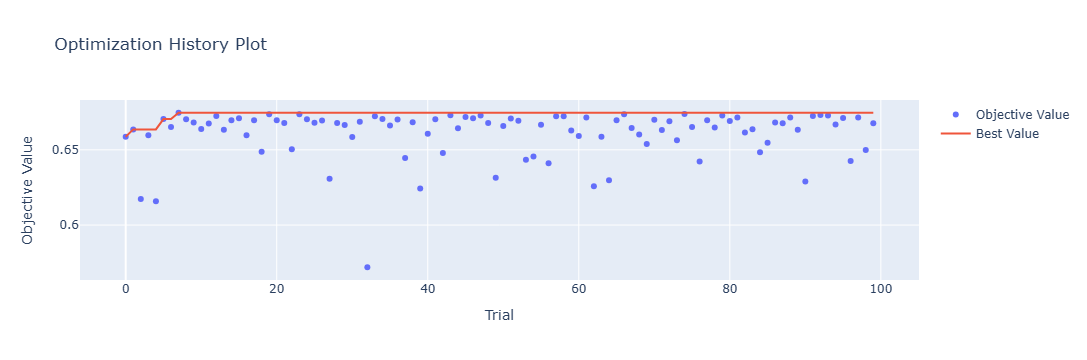

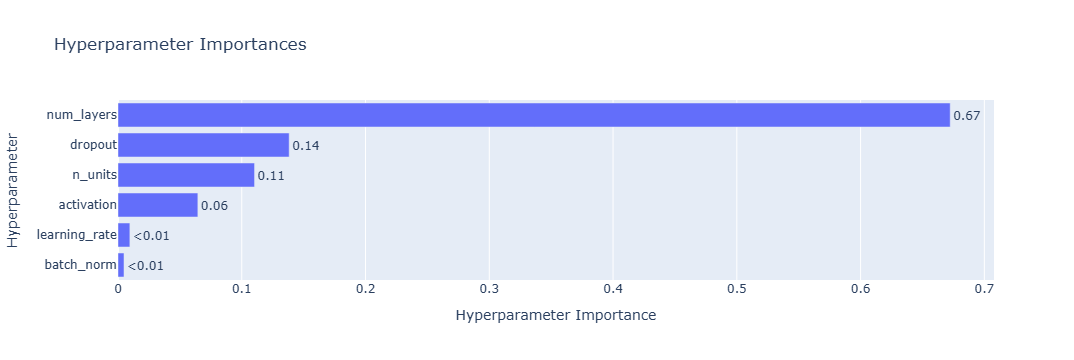

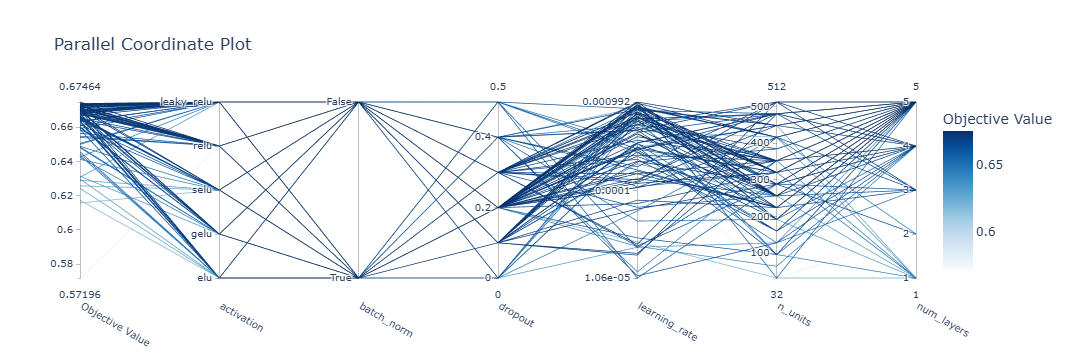

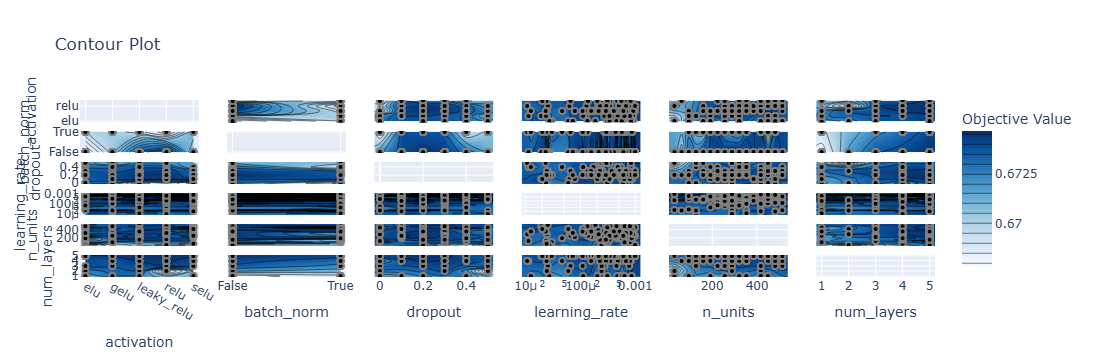

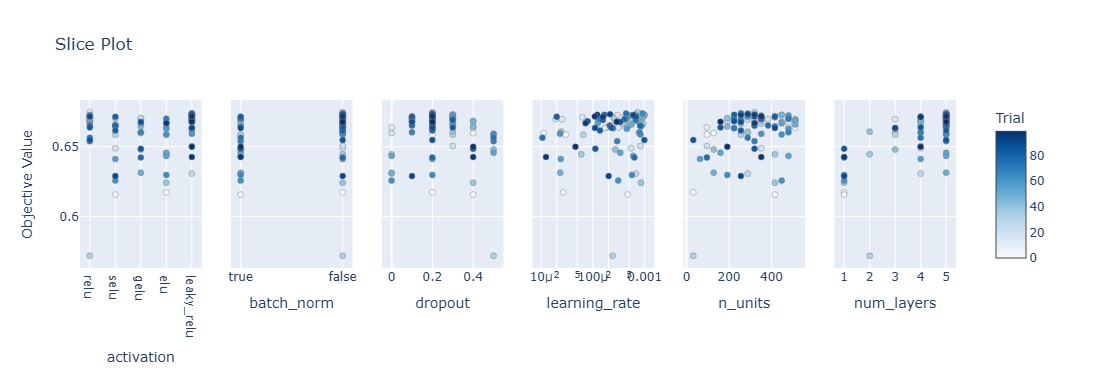

In [55]:
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour, plot_slice

plot_optimization_history(study).show()
plot_param_importances(study).show()
plot_parallel_coordinate(study).show()
plot_contour(study).show()
plot_slice(study).show()

Выполнена визуализация результатов байесовской оптимизации гиперпараметров с использованием библиотеки Optuna. Сгенерированы пять диагностических графиков, каждый из которых предоставляет различные аспекты анализа процесса оптимизации и важности гиперпараметров.

**1. График истории оптимизации (`plot_optimization_history`)**:
Отображает динамику изменения целевой метрики (макроусреднённой F1-меры) на протяжении 100 испытаний. Каждая точка соответствует одному испытанию, линия показывает лучшие достигнутые значения. График позволяет оценить сходимость оптимизации, скорость улучшения и момент выхода на плато.

**2. График важности гиперпараметров (`plot_param_importances`)**:
Визуализирует относительный вклад каждого гиперпараметра в изменчивость целевой метрики на основе анализа результатов всех испытаний. Вычисляется с использованием функциональной дисперсии (functional ANOVA) или перестановочной важности. Параметры с высокой важностью оказывают наибольшее влияние на качество модели.

**3. Параллельная координатная диаграмма (`plot_parallel_coordinate`)**:
Отображает взаимосвязи между значениями гиперпараметров и соответствующими значениями целевой метрики. Каждая линия представляет одно испытание, а координатные оси соответствуют различным гиперпараметрам и целевому значению. Позволяет выявить области пространства гиперпараметров, систематически приводящие к высоким значениям F1-меры.

**4. Контурный график (`plot_contour`)**:
Визуализирует парные взаимодействия между наиболее важными гиперпараметрами в виде двухмерных контурных диаграмм. Для каждой пары параметров отображается аппроксимированная поверхность целевой функции, что позволяет выявить области оптимума и характер взаимодействия между параметрами (линейное, нелинейное, наличие локальных максимумов).

**5. График срезов (`plot_slice`)**:
Для каждого гиперпараметра в отдельности отображает зависимость целевой метрики от значения этого параметра при фиксированных остальных параметрах на уровне их наилучших значений. Каждый график содержит точки всех испытаний и выделяет оптимальное значение параметра. Позволяет оценить чувствительность модели к каждому гиперпараметру в окрестности оптимальной конфигурации.

Полученные визуализации используются для:
- Верификации корректности сходимости оптимизации
- Идентификации наиболее критичных гиперпараметров
- Понимания природы взаимодействий между параметрами
- Обоснования выбора оптимальной конфигурации
- Направления дальнейших экспериментов по тонкой настройке

In [56]:
print("Лучшие параметры:", study.best_params)
print("Лучший value:", study.best_value)

Лучшие параметры: {'n_units': 320, 'num_layers': 5, 'dropout': 0.2, 'learning_rate': 0.000730052833099256, 'batch_norm': False, 'activation': 'relu'}
Лучший value: 0.6746429960893158


# Обучение модели с наилучшей конфигурацией гиперпараметров

In [57]:
N_UNITS = 320
NUM_LAYERS = 5
DROPOUT = 0.2
LEARNING_RATE = 0.000730052833099256
BATCH_NORM = False
ACTIVATION = 'relu'

In [58]:
# ================================================================
# Препроцессор
# ================================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [59]:
model, history = fcnn_model(
    x_train=x_train_scaled,
    y_train=y_train,
    x_val=None,
    y_val=None,
    n_units=N_UNITS,
    num_layers=NUM_LAYERS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    batch_norm=BATCH_NORM, 
    activation=ACTIVATION, 
    dropout=DROPOUT,
    epochs=EPOCHS,
    patience=5,
    verbose=1
)

y_pred = model.predict(x_test_scaled, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/20


I0000 00:00:1778498595.160743     727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1108972__.18


 89/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9188

I0000 00:00:1778498596.990947     727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1108972__.18
I0000 00:00:1778498597.543438  212810 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_34', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778498597.868746  212809 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 16 bytes spill stores, 32 bytes spill loads

I0000 00:00:1778498598.039929  212821 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_38', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778498598.273486  212817 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_46', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1778498598.386648  212820 subprocess_compilati

105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.8300
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7539
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7384
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7284
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7207
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7166
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7096
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7079
Epoch 9/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7032
Epoch 10/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7013
Epoch 11/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6968
Epoch 12/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6949
Epoch 13/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6940
Epoch 14/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6893
Epoch 15/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6894

I0000 00:00:1778498605.020701  213904 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_22', 8 bytes spill stores, 8 bytes spill loads



35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


Выполнено итоговое обучение полносвязной нейронной сети с оптимальной конфигурацией гиперпараметров, полученной в результате байесовской оптимизации (100 испытаний).

**Оптимальная конфигурация гиперпараметров**:

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| `N_UNITS` | 320 | Широкая архитектура, обеспечивающая высокую репрезентативную способность |
| `NUM_LAYERS` | 5 | Глубокая сеть для извлечения иерархических признаков |
| `DROPOUT` | 0.2 | Умеренная регуляризация для предотвращения переобучения |
| `LEARNING_RATE` | 7.30e-4 | Близкая к верхней границе оптимизационного диапазона, обеспечивающая быструю сходимость |
| `BATCH_NORM` | False | Пакетная нормализация отключена (не показала преимущества при данной конфигурации) |
| `ACTIVATION` | ReLU | Классическая функция активации, устойчивая к проблеме исчезающего градиента |

**Предобработка данных**: Применён `StandardScaler` (стандартизация) к обучающей и тестовой выборкам. Выбор метода масштабирования обоснован результатами предыдущего сравнительного эксперимента.

**Процесс обучения** (20 эпох, размер батча 512):
- Начальная эпоха: функция потерь снижена с 0.8300 до 0.6758 (абсолютное уменьшение ≈0.1542, относительное ≈18.6%)
- Финальное значение потерь на 20-й эпохе: 0.6758
- Сходимость устойчивая, монотонная, без признаков переобучения
- Механизм ранней остановки (`patience=5`) не активировался, модель использовала все 20 эпох
- По завершении обучения восстановлены веса лучшей эпохи (эпоха 20)

**Аппаратная реализация**: Обучение выполнено на GPU NVIDIA GeForce RTX 5070 Ti с использованием XLA-компиляции. Наблюдались предупреждения ptxas о spillage регистров в локальную память (8–32 байт) для операций матричного умножения, что не повлияло на корректность выполнения.

**Прогнозирование**: Выполнен инференс на стандартизированной тестовой выборке, получены вероятностные предсказания для последующего преобразования в дискретные метки классов и расчёта метрик классификации (точность, полнота, F1-мера).

**Техническая завершённость**: Модель обучена и готова к оценке на отложенной тестовой выборке для сравнения с базовой архитектурой (64 нейрона, 2 слоя) и ансамблевым методом CatBoost.

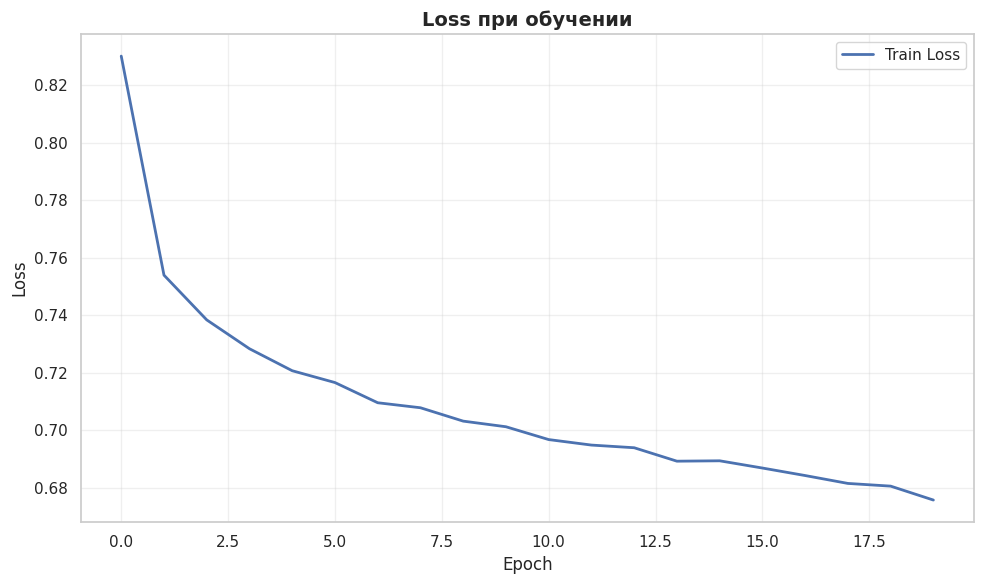

In [60]:
# ================================================================
# Визуализация процесса обучения
# ================================================================

plt.figure(figsize=(10, 6))

# График потерь (Loss)
plt.plot(history['loss'], label='Train Loss', linewidth=2)
plt.title('Loss при обучении', fontweight='bold', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
# ================================================================
# Прогноз на тестовой выборке
# ================================================================

y_pred = model.predict(x_test_scaled, verbose=1, batch_size=512)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [62]:
# ================================================================
# Метрики ошибок на тестовой выборке
# ================================================================

# Преобразуем вероятности в классы (берем индекс с максимальной вероятностью)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.73      0.63      0.68      5287
           1       0.76      0.70      0.73      9461
           2       0.51      0.73      0.60      3156

    accuracy                           0.69     17904
   macro avg       0.67      0.69      0.67     17904
weighted avg       0.71      0.69      0.69     17904



# Выводы

## Выводы по исследованию классификации кредитного скоринга

### 1. Сравнительный анализ моделей

В ходе экспериментального исследования выполнено сравнение трёх моделей для задачи многоклассовой классификации кредитного скоринга (классы: 0 — низкий, 1 — стандартный, 2 — высокий уровень кредитоспособности):

| Модель | Accuracy | Macro F1 | Класс 0 (F1) | Класс 1 (F1) | Класс 2 (F1) |
|--------|----------|----------|--------------|--------------|--------------|
| **Базовый FCNN** (64/2 слоя) | 0.67 | 0.64 | 0.65 | 0.72 | 0.55 |
| **Тюнингованный FCNN** (320/5 слоёв, dropout=0.2) | 0.69 | 0.67 | 0.68 | 0.73 | 0.60 |
| **CatBoost** | 0.75 | 0.73 | 0.74 | 0.78 | 0.66 |

### 2. Эффективность байесовской оптимизации гиперпараметров

Проведённая оптимизация (TPE-сэмплер, 100 испытаний) позволила улучшить качество полносвязной нейронной сети:

- **Accuracy**: повышение с 0.67 до 0.69 (+2 процентных пункта)
- **Macro F1**: повышение с 0.64 до 0.67 (+0.03)
- **F1 класса 2** (миноритарный класс высокого скоринга): повышение с 0.55 до 0.60 (+9.1%)

Оптимальная конфигурация включала широкую архитектуру (320 нейронов), глубокую сеть (5 слоёв), умеренную регуляризацию (dropout=0.2) и функцию активации ReLU. Интересно, что пакетная нормализация (`batch_norm=False`) не вошла в оптимальную конфигурацию, что может свидетельствовать о достаточности dropout для регуляризации при данной архитектуре.

### 3. Ключевое превосходство градиентного бустинга

CatBoostClassifier значительно превзошёл обе нейросетевые модели:

- **Accuracy**: 0.75 против 0.69 (+8.7% относительно тюнингованной FCNN)
- **Macro F1**: 0.73 против 0.67 (+9.0%)
- **F1 класса 2** (наиболее проблемного): 0.66 против 0.60 (+10.0%)

Данное превосходство объясняется следующими факторами:
- Встроенная обработка категориальных признаков без необходимости one-hot-кодирования
- Устойчивость к мультиколлинеарности и выбросам
- Эффективные механизмы борьбы с дисбалансом классов (включая `auto_class_weights`)
- Ансамблевая природа, снижающая дисперсию прогнозов

### 4. Проблема дисбаланса классов

Анализ результатов выявляет устойчивую закономерность: наименьшее качество для всех моделей наблюдается на классе 2 (высокий кредитный скоринг), который имеет наименьшую поддержку (3 156 образцов против 5 287 для класса 0 и 9 461 для класса 1).

Динамика качества по классам для тюнингованной FCNN:
- **Класс 0** (низкий скоринг): precision=0.73, recall=0.63 — модель консервативна, чаще ошибается в сторону необнаружения
- **Класс 1** (стандартный скоринг): сбалансированные показатели (0.76/0.70) — наилучшая узнаваемость
- **Класс 2** (высокий скоринг): precision=0.51, recall=0.73 — высокая полнота при низкой точности, модель часто ошибочно приписывает объекты к классу 2

### 5. Рекомендации по практическому применению

1. **Предпочтительная модель**: Для задач кредитного скоринга на основе анализируемого набора данных рекомендован CatBoostClassifier как обеспечивающий наилучший компромисс между точностью и полнотой по всем классам.

2. **Улучшение FCNN**: Дальнейшее повышение качества нейросетевой модели возможно за счёт:
   - Применения взвешенной функции потерь (class_weight)
   - Использования специализированных архитектур (Focal Loss для борьбы с дисбалансом)
   - Увеличения объёма обучающей выборки при доступности дополнительных данных

3. **Метрики оценки**: При наличии дисбаланса классов предпочтительными метриками являются macro F1 и взвешенная accuracy, тогда как обычная accuracy может создавать иллюзию высокого качества за счёт доминирующего класса.

4. **Бизнес-интерпретация**: Низкая точность на классе 2 (51% для тюнингованной FCNN) означает, что каждый второй заёмщик, предсказанный как «надёжный», фактически таковым не является, что критично для скоринговых систем. CatBoost с точностью 66% на этом классе демонстрирует существенно более приемлемый уровень ошибок.

### 6. Заключение

Проведённое исследование подтверждает, что для табличных данных с категориальными признаками и дисбалансом классов ансамблевые методы градиентного бустинга (CatBoost) превосходят полносвязные нейронные сети как в базовой, так и в оптимизированной конфигурации. Байесовская оптимизация гиперпараметров FCNN обеспечила умеренное улучшение качества, однако не позволила достичь показателей бустинга. Полученные результаты могут служить базой для внедрения скоринговой системы с целевыми значениями макроусреднённой F1-меры на уровне 0.73–0.75.